In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download("all")
import re

from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\91797\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\91797\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\91797\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\91797\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\91797\AppData\Roaming\nltk_data...
[

In [5]:
data = pd.read_csv("dataset-P676-converted-1.csv")


In [6]:
data

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [7]:
data.shape

(1440, 3)

In [8]:
data.columns

Index(['title', 'rating', 'body'], dtype='object')

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [10]:
# Merging title and body
data['review'] = data['title']+' ' +data['body']
data

,title,rating,body,review
0,Horrible product,1,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is not like 48 megapixel Camera...
2,Overall,4,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...
...,...,...,...,...
1435,Excellent mobile,5,Excellent mobile,Excellent mobile Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve...",Never expected from samsung All over mobile pe...
1437,Good value for money,5,Battery life is good but camera clarity could ...,Good value for money Battery life is good but ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied.....",Unreal and whitish display It's a very bad pro...


In [11]:
# Taking the required column
data =data[['review','rating']]
data

,review,rating
0,Horrible product Very disappointed with the ov...,1
1,Camera quality is not like 48 megapixel Camera...,3
2,"Overall Got the mobile on the launch date,Batt...",4
3,A big no from me 1. It doesn't work with 5.0GH...,1
4,Put your money somewhere else Not worth buying...,1
...,...,...
1435,Excellent mobile Excellent mobile,5
1436,Never expected from samsung All over mobile pe...,1
1437,Good value for money Battery life is good but ...,5
1438,Unreal and whitish display It's a very bad pro...,1


# EDA

In [12]:
# Check total rows and column
data.shape

(1440, 2)

In [13]:
# dataset has 1440 rows and 2 columns

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1440 non-null   object
 1   rating  1440 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 22.6+ KB


In [15]:
# Statistical Data
data.describe()

,rating
count,1440.000000
mean,3.173611
std,1.584453
min,1.000000
25%,1.000000
50%,4.000000
75%,5.000000
max,5.000000


In [16]:
# The average rating is 3.17 which indicates that majority reviews are moderately positive sentiment
# The median rating is 4 which shows that most of the reviews are positive.

In [17]:
# Checking Null Values
data.isnull().sum()

review    0
rating    0
dtype: int64

In [18]:
# This dataset has no null values

In [19]:
# Checking duplicate values
data.duplicated().sum()

np.int64(0)

In [20]:
# this dataset contains no dupicate value.

# Text Preprocesing

In [21]:
# Load English stopwords
stop_words = set(stopwords.words('english'))

In [22]:
# Function for datacleaning
def clean_text(text):

    # Convert into Lower Case
    text = text.lower()

    # Remove Special Characters, Numbers and anything that is not a english letter
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words=[word for word in words if word not in stop_words]

    # Join words back to sentence
    return ' '.join(words)

# Apply Cleaning function
data['review']= data['review'].apply(clean_text)

In [23]:
data.head(10)

,review,rating
0,horrible product disappointed overall performa...,1
1,camera quality like megapixel camera quality low,3
2,overall got mobile launch date battery must ap...,4
3,big work ghz wifi frequency ghz old school cam...,1
4,put money somewhere else worth buying faulty s...,1
5,much lagging slow never purchase samsung phone...,1
6,worst samsung mobile ever worst samsung mobile...,1
7,pm,1
8,slow performance phone hangs lot slow received...,1
9,buy amazon poor quality camera found box seal ...,1


In [24]:
# Segregating positive reviews and negative reviews
# Postive reviews >= 3
# Negative reviews < 3

def sentiment_label(rating):
    if rating >= 3:
        return "Positive"

    else:
        return " Negative"


In [25]:
data['sentiment'] = data['rating'].apply(sentiment_label)

In [26]:
data.head(10)

,review,rating,sentiment
0,horrible product disappointed overall performa...,1,Negative
1,camera quality like megapixel camera quality low,3,Positive
2,overall got mobile launch date battery must ap...,4,Positive
3,big work ghz wifi frequency ghz old school cam...,1,Negative
4,put money somewhere else worth buying faulty s...,1,Negative
5,much lagging slow never purchase samsung phone...,1,Negative
6,worst samsung mobile ever worst samsung mobile...,1,Negative
7,pm,1,Negative
8,slow performance phone hangs lot slow received...,1,Negative
9,buy amazon poor quality camera found box seal ...,1,Negative


In [27]:
# Character count
data['char_count']= data['review'].apply(len)

# word Count
data['word_count'] = data['review'].apply(lambda x : len(x.split()))
    

In [28]:
data.head(10)

,review,rating,sentiment,char_count,word_count
0,horrible product disappointed overall performa...,1,Negative,57,6
1,camera quality like megapixel camera quality low,3,Positive,48,7
2,overall got mobile launch date battery must ap...,4,Positive,275,39
3,big work ghz wifi frequency ghz old school cam...,1,Negative,205,34
4,put money somewhere else worth buying faulty s...,1,Negative,164,27
5,much lagging slow never purchase samsung phone...,1,Negative,96,15
6,worst samsung mobile ever worst samsung mobile...,1,Negative,147,24
7,pm,1,Negative,2,1
8,slow performance phone hangs lot slow received...,1,Negative,73,10
9,buy amazon poor quality camera found box seal ...,1,Negative,158,25


In [29]:
data.describe()

,rating,char_count,word_count
count,1440.000000,1440.000000,1440.000000
mean,3.173611,222.954861,33.606250
std,1.584453,153.582528,23.331073
min,1.000000,0.000000,0.000000
25%,1.000000,136.000000,20.000000
50%,4.000000,187.000000,28.000000
75%,5.000000,264.000000,40.000000
max,5.000000,1855.000000,275.000000


In [30]:
data['rating'].value_counts()

rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64

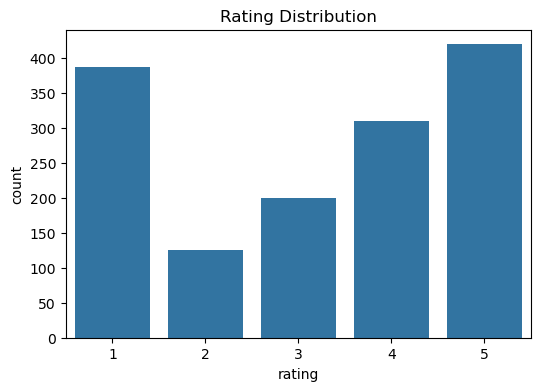

In [31]:
# Rating Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='rating',data=data)
plt.title("Rating Distribution")
plt.show()

In [32]:
# Ratings 1 and 5 dominate- users tend to have very negative or very postive reviews. Lower ratings such as 1 and 2 represent negative sentiments.

Text(0, 0.5, 'Frequency')

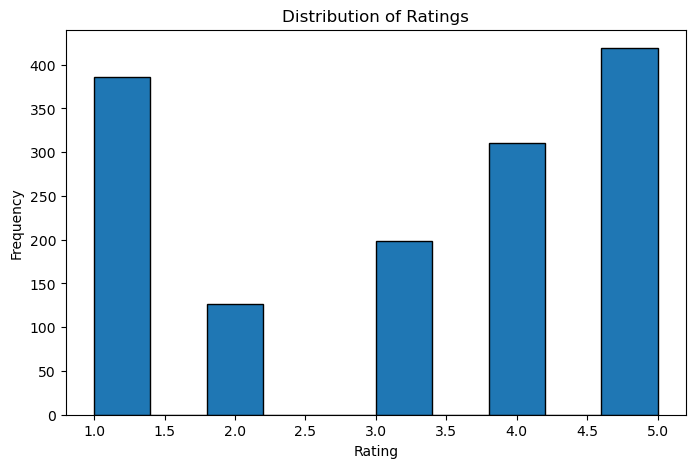

In [33]:
# Histogram Rating Distribution
plt.figure(figsize=(8,5))
plt.hist(data['rating'], bins=10, edgecolor ='black')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

In [34]:
# Most of ratings lies between 4 and 5

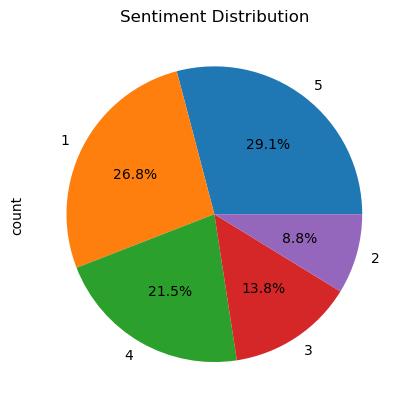

In [35]:
# Pie Chart
data['rating'].value_counts().plot(kind='pie', autopct ='%1.1f%%')
plt.title("Sentiment Distribution")
plt.show()

In [36]:
# The Ratings 5 and 4 consists of 51% of total ratings which is positive.
# The ratings 1 and 2 consists of approx of 35 % of total reviews which are negative
# The remaining reviews which is about 14 % are neutral reviews

In [37]:
data['sentiment'].value_counts()

sentiment
Positive     928
 Negative    512
Name: count, dtype: int64

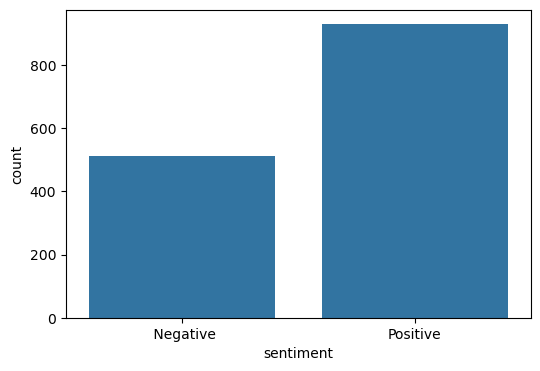

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment',data=data)
plt.show()

In [39]:
# Positive review is higher in number

In [40]:
# Percentage of individual sentiment
sentiment_percentage = round((data['sentiment'].value_counts(normalize=True)*100),2)
sentiment_percentage

sentiment
Positive     64.44
 Negative    35.56
Name: proportion, dtype: float64

In [41]:
# most common word
from collections import Counter

word= " ".join(data['review']).split()
common_word = Counter(word).most_common(10)
common_word

[('phone', 1881),
 ('good', 1479),
 ('camera', 1083),
 ('battery', 896),
 ('samsung', 807),
 ('quality', 722),
 ('mobile', 620),
 ('price', 457),
 ('product', 432),
 ('buy', 345)]

In [42]:
# Segregating all Postive words
positive_word = " ".join(data[data['sentiment']=='Positive']['review']).split()
Counter(positive_word).most_common(10)

[('good', 1289),
 ('phone', 1239),
 ('camera', 783),
 ('battery', 721),
 ('quality', 471),
 ('samsung', 429),
 ('price', 399),
 ('mobile', 329),
 ('life', 264),
 ('best', 249)]

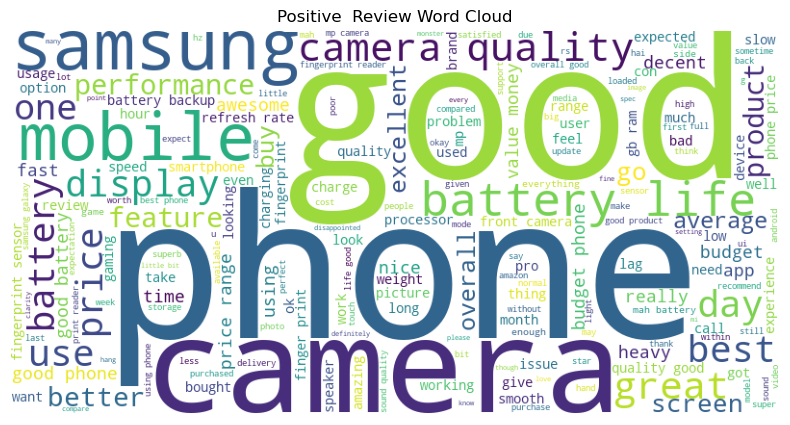

In [43]:
# Create word cloud for positive words
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(positive_word))

# Plot 
plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Positive  Review Word Cloud')
plt.show()


In [44]:
# Create Wordcloud for negative reviews
negative_word = " ".join(data[data['sentiment']==' Negative']['review']).split()
Counter(negative_word).most_common(10)

[('phone', 642),
 ('samsung', 378),
 ('camera', 300),
 ('mobile', 291),
 ('quality', 251),
 ('product', 224),
 ('buy', 217),
 ('worst', 198),
 ('good', 190),
 ('amazon', 187)]

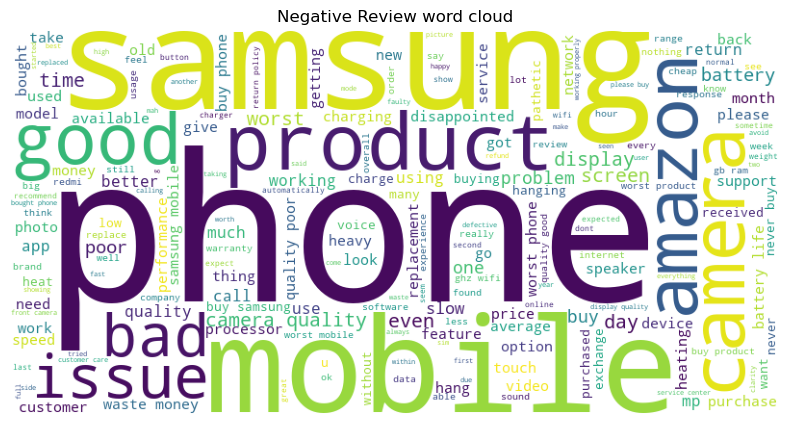

In [45]:
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(negative_word))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Negative Review word cloud')
plt.show()

In [46]:
# Convert Positive words to a set for efficient output
positive_word_set = set(positive_word)

# Remove words from negative word that are also present in positive word set

filtered_negative_word = [word for word in negative_word if word not in positive_word_set]
Counter(filtered_negative_word).most_common(10)

[('defective', 19),
 ('replaced', 14),
 ('refund', 13),
 ('cheated', 12),
 ('mic', 11),
 ('cheating', 9),
 ('frequently', 9),
 ('rd', 8),
 ('asked', 8),
 ('visit', 8)]

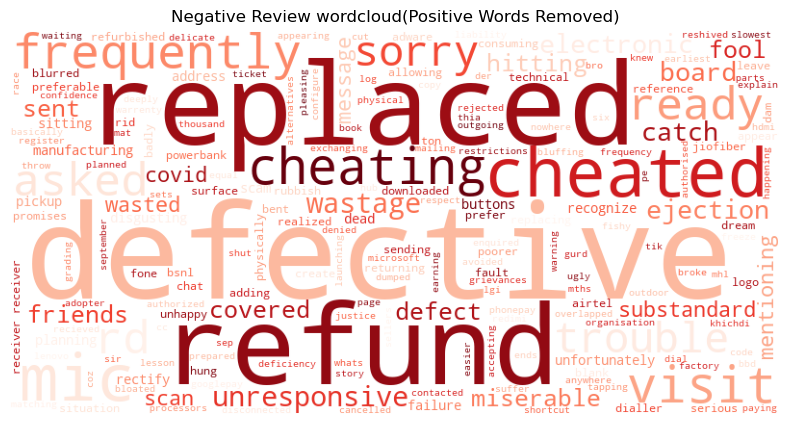

In [47]:
# Create word Cloud from  the filtered negative words

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(" ".join(filtered_negative_word))
plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Negative Review wordcloud(Positive Words Removed)')
plt.show()

In [48]:
data

,review,rating,sentiment,char_count,word_count
0,horrible product disappointed overall performa...,1,Negative,57,6
1,camera quality like megapixel camera quality low,3,Positive,48,7
2,overall got mobile launch date battery must ap...,4,Positive,275,39
3,big work ghz wifi frequency ghz old school cam...,1,Negative,205,34
4,put money somewhere else worth buying faulty s...,1,Negative,164,27
...,...,...,...,...,...
1435,excellent mobile excellent mobile,5,Positive,33,4
1436,never expected samsung mobile performance poor...,1,Negative,156,22
1437,good value money battery life good camera clar...,5,Positive,90,14
1438,unreal whitish display bad product highly diss...,1,Negative,160,22


In [49]:
# Bigram Analysis : consecutive two words coming together

from nltk.util import ngrams

token = word
bigram = list(ngrams(token,2))
bigram_freq = Counter(bigram)
bigram_freq.most_common(10)

[(('camera', 'quality'), 306),
 (('battery', 'life'), 284),
 (('good', 'phone'), 125),
 (('price', 'range'), 124),
 (('good', 'battery'), 104),
 (('budget', 'phone'), 100),
 (('quality', 'good'), 97),
 (('value', 'money'), 95),
 (('battery', 'backup'), 93),
 (('phone', 'good'), 90)]

In [50]:
# Trigram Analysis :  Consecutive three words coming together

token = word
trigram = list(ngrams(token,3))
trigram_freq = Counter(trigram)
trigram_freq.most_common(10)

[(('battery', 'life', 'good'), 52),
 (('camera', 'quality', 'good'), 52),
 (('good', 'battery', 'life'), 43),
 (('media', 'could', 'loaded'), 34),
 (('camera', 'quality', 'poor'), 33),
 (('finger', 'print', 'reader'), 30),
 (('hz', 'refresh', 'rate'), 27),
 (('good', 'camera', 'quality'), 25),
 (('gb', 'ram', 'gb'), 24),
 (('good', 'budget', 'phone'), 23)]

# Model Building and Evaluation

In [73]:
from sklearn.model_selection import  train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB



from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix,precision_score,recall_score,f1_score)

In [52]:
data

,review,rating,sentiment,char_count,word_count
0,horrible product disappointed overall performa...,1,Negative,57,6
1,camera quality like megapixel camera quality low,3,Positive,48,7
2,overall got mobile launch date battery must ap...,4,Positive,275,39
3,big work ghz wifi frequency ghz old school cam...,1,Negative,205,34
4,put money somewhere else worth buying faulty s...,1,Negative,164,27
...,...,...,...,...,...
1435,excellent mobile excellent mobile,5,Positive,33,4
1436,never expected samsung mobile performance poor...,1,Negative,156,22
1437,good value money battery life good camera clar...,5,Positive,90,14
1438,unreal whitish display bad product highly diss...,1,Negative,160,22


In [54]:
# Spit in dependent and independent variable
X = data[['review']]
Y = data['sentiment']


In [57]:
X .head(10)

,review
0,horrible product disappointed overall performa...
1,camera quality like megapixel camera quality low
2,overall got mobile launch date battery must ap...
3,big work ghz wifi frequency ghz old school cam...
4,put money somewhere else worth buying faulty s...
5,much lagging slow never purchase samsung phone...
6,worst samsung mobile ever worst samsung mobile...
7,pm
8,slow performance phone hangs lot slow received...
9,buy amazon poor quality camera found box seal ...


In [58]:
Y.head(10)

0     Negative
1     Positive
2     Positive
3     Negative
4     Negative
5     Negative
6     Negative
7     Negative
8     Negative
9     Negative
Name: sentiment, dtype: object

In [59]:
# Feature Extraction Using TF-IDF
# TF-IDF -> It is used to convert text data into numerical feature.
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=2000) # Keep only the top 2000 most important words from the entire dataset 
# because using all the words makes the  training very slow , uses more memory and may reduce the performance

In [62]:
# fit transform
X = tfidf.fit_transform(data['review'])
Y = data['sentiment']

In [65]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 35431 stored elements and shape (1440, 2000)>

In [63]:
X.shape

(1440, 2000)

In [66]:
# 1440 ro3ws - Total number of reviews/documents in tour dataset
# 2000 columns - Total number of features(words/term) created by the TF-IDF vectorizer

In [68]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train,Y_test = train_test_split(X,Y,test_size = 0.2, random_state=42)

In [70]:
X_train.shape,X_test.shape

((1152, 2000), (288, 2000))

In [71]:
Y_train.shape, Y_test.shape

((1152,), (288,))

In [85]:
# Label Encoding
# it converts categorical labels into numerical values
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

Y_train = le.fit_transform(Y_train)
Y_test = le.transform(Y_test)

In [86]:
# Model 1- Logistic Regression
lr = LogisticRegression(max_iter = 100) # Maximum no. of training iteration to 100

# Model 2 - Decsion Tree
dt = DecisionTreeClassifier()

# Model 3 -SVM
svm = LinearSVC()

# Model 4 - Naive Bayes
nb = MultinomialNB()

# Model 5 - XGBoost
xgb = XGBClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 3)
# N_estimators -> It shows no. of trees to build, learning_rate controls how much each new tree contributes to the final prediction
# Maqx_depth controls tree complexity

# Evaluation

In [87]:
# Created a fucntion for Model Evaluation
def evaluate_model(model_name, model):
    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    print("\n" + "="*60)

    print("MODEL:",model_name)

    print("+"*60)

    #Accuracy
    accuracy = accuracy_score(Y_test,Y_pred)

    #Precision
    precision = precision_score(Y_test,Y_pred,average="weighted")

    #Recall
    recall = recall_score(Y_test,Y_pred,average="weighted")

    f1 = f1_score(Y_test,Y_pred,average="weighted")
    cm = confusion_matrix(Y_test,Y_pred)

    print("Accuracy :", accuracy)

    print("Precision :", precision)

    print("Recall:", recall)

    print("F1 Score :", f1)

    print("\nConfusion Matrix\n")
    print(cm)

    print("\nClassification Report\n")
    print(classification_report(Y_test,Y_pred))


In [88]:

#Accuracy-> Total Correct predictions
#Precison -> How many predicted labels are corrcet
#Recall -> How many actual labels are captured
#F1 score -> Balance of precision and recall
#Confusion Matrix -> actual vs Predicted values
#Classification Report  shows how the model predicts Negative and Positive reviews


evaluate_model("Logistic Regression",lr)
evaluate_model( "Decision Tree",dt)
evaluate_model("svm",svm)
evaluate_model("Naive Bayes", nb)



MODEL: Logistic Regression
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Accuracy : 0.875
Precision : 0.8834758041147492
Recall: 0.875
F1 Score : 0.8709854994629431

Confusion Matrix

[[ 80  31]
 [  5 172]]

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.72      0.82       111
           1       0.85      0.97      0.91       177

    accuracy                           0.88       288
   macro avg       0.89      0.85      0.86       288
weighted avg       0.88      0.88      0.87       288


MODEL: Decision Tree
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Accuracy : 0.7881944444444444
Precision : 0.7859596631205673
Recall: 0.7881944444444444
F1 Score : 0.7858650371139821

Confusion Matrix

[[ 75  36]
 [ 25 152]]

Classification Report

              precision    recall  f1-score   support

           0       0.75      0.68      0.71       111
           1       0.81      0.86      0.83       

In [89]:
evaluate_model( "XGBoost", xgb)


MODEL: XGBoost
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Accuracy : 0.8958333333333334
Precision : 0.896109096203738
Recall: 0.8958333333333334
F1 Score : 0.8948074331329049

Confusion Matrix

[[ 91  20]
 [ 10 167]]

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.82      0.86       111
           1       0.89      0.94      0.92       177

    accuracy                           0.90       288
   macro avg       0.90      0.88      0.89       288
weighted avg       0.90      0.90      0.89       288



In [92]:
# Final comparison Tbale
results = pd.DataFrame({"model":["Logistic regression","Decision Tree","SVM", "Naive Bayes","XGBoost"],
                            "Accuracy":[87.5, 78.81, 87.54, 84.84,89.58]})
results

,model,Accuracy
0,Logistic regression,87.50
1,Decision Tree,78.81
2,SVM,87.54
3,Naive Bayes,84.84
4,XGBoost,89.58


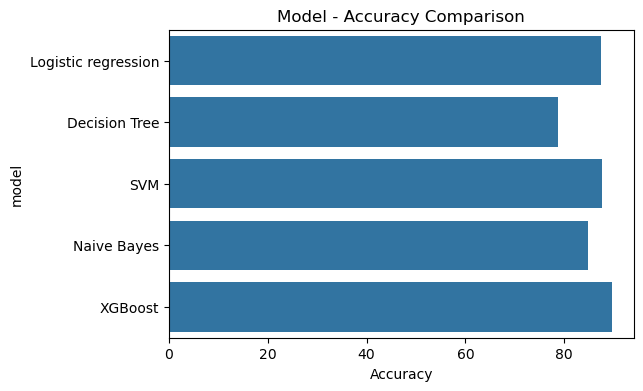

In [96]:
plt.figure(figsize=(6,4))
sns.barplot(x="Accuracy",y="model",data = results)
plt.title("Model - Accuracy Comparison")
plt.show()

# Conclusion

##### Among all the models evaluated, XGBoost achieved the highest accuracy(89.58%) , making it the best performing model for sentiment classification 
##### on this dataset. Logistic Regression and SVM also performed well with accuracies above 87%, while Decision Tree showed the lowest performance
##### Threfore XGBoost is selected as final due to its higher accuracy.

#### Output from Confusion Matrix (shows exactly where model is making mistakes) for XGBoost

##### TN = 91 -> 91 negative reviews were correctly predicted as negative
##### FP = 20 -> 20 negative reviews were incorectly predicted as negative
##### FN = 10 -> 10 positive reviews are incorectly predicted as negative
##### TP=167 -> 167 positive reviews were correctly predicted as positive

#### Output from classification report of XGBoost

#### Negative Reviews

##### Precision = 0.90(90%): when a model predicts a review as Negative, it is correct 90% of the time
##### Recall = 0.82 (82%): Out of 111 actual Negative reviews, the model corrcetly identified 82% which means model succesfully detected most negative 
##### revies but still missed about 18%
##### F1-Score = 0.86(*(%) : The model performs well in recognizing Negative sentiment

#### Positive Reviews

##### Precision = 0.89(89%): Out of all reviews predicted as Positive, 89% were actually Positive
##### Recall = 0.94(94%): Out of 177 actual Positivr reviews the model correctly identified 95%.
##### F1-Score = 0.86(86%): Very strong performance for positive sentiment classification

# Model Deployment

##### This file list all the Python packages required to run Streamlit application 

In [99]:
%%writefile requirements.txt
pandas
numpy
scikit-learn
nltk
streamlit
openpyxl

Writing requirements.txt


#### create train_model.py

In [116]:
%%writefile train_model.py
import pandas as pd # for handling datasets and dataframes
import re # regular expression library: used for text cleaning.
import pickle # Used to save and load trained models.
import nltk # for text preprocessing

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer # Converts text data into numerical features.
from xgboost import XGBClassifier

nltk.download("punkt")
nltk.download("stopwords")


# Laod Dataset
data = pd.read_csv("dataset-P676-converted-1.csv")

#Merge columns
data['review'] = (data['title'].astype(str) + " " +data['body'].astype(str))

# Keep required columns
data = data[["review", "rating"]]

# stopwords
stop_words = set(stopwords.words("english"))

# Cleaning Function
def clean_text(text):
    
    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = word_tokenize(text)

    words = [ w for w in words if w not in stop_words ]

    return " ".join(words)

    
# Clean text
data["review"] = data["review"].apply(clean_text)

# Sentiment levels
def sentiment_label(rating):

    if rating >= 3:
        return "Positive"

    return "Negative"

data["sentiment"] = data["rating"].apply(sentiment_label)

# TFIDF 
tfidf = TfidfVectorizer(max_features = 2000)
X = tfidf.fit_transform(data["review"])
Y= data["sentiment"]

# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train,Y_test = train_test_split(X,Y,test_size = 0.2, random_state=42)


# Encoding

le = LabelEncoder()

Y_encoded = le.fit_transform(Y)


# Train Model
xgb = XGBClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 3)
xgb.fit(X ,Y_encoded)

# save TFIDF 
with open("tfidf_vectorizer.pkl", "wb") as f:# Creates binary file

    pickle.dump(tfidf, f) # saves TF-IDF vocabulary and settings

# File Created : tfidf_vectorizer.pkl

# save Model
with open( "xgb_model.pkl", "wb") as f: # Creates binary file

    pickle.dump(xgb, f) # stores trained XGB model

print("Model Saved succesully")



Overwriting train_model.py


#### Create app.py

In [118]:
%%writefile app.py
import streamlit as st # Used to create web application interface
import pickle # Loads the trained model and tf-idf vectorizer
import re # for text cleaning with regular expressions
import nltk # for preprocessing text

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)

# laod files
with open ("tfidf_vectorizer.pkl", "rb") as f:
    tfidf = pickle.load(f)

with open("xgb_model.pkl", "rb") as f:
    model = pickle.load(f)

stop_words = set(stopwords.words("english"))

# Cleaning
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]',' ',text)

    words = word_tokenize(text)

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

# Prediction
def predict_sentiment(text):# Functions that predicts sentiment

    cleaned = clean_text(text)

    vector = tfidf.transform([cleaned]) # transforms cleaned text into numerical features

    prediction = model.predict(vector)

    return prediction[0]


# streamlit UI
st.set_page_config( page_title="Sentiment Analysis", layout="centered") # Page title

st.title("Sentiment Analysis App") # Browser tab title.

review = st.text_area("Enter Review")

if st.button("Predict"):
    
    if review:
        result = predict_sentiment(review)
        if result == 1:
            st.success("Positive Review ! Yay!")
        else:
            st.error("negative Review ! Ohh no")

       
    else:
        st.warning("Enter review text")


Overwriting app.py


In [106]:
import os 
print(os.getcwd())
print(os.listdir())

C:\Users\91797\NLP_Project
['.ipynb_checkpoints', 'app.py', 'dataset-P676-converted-1.csv', 'NLP.ipynb', 'requirements.txt', 'train_model.py']
